<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/01_dataset_ingestion_and_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
## Google Colab Restart cell

# Use cell whenever Colab reconnects
from google.colab import drive
from pathlib import Path
import pandas as pd

drive.mount("/content/drive")

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

AUDIO_DIR = (
    RAW_ROOT
    / "dataset"
    / "audio"
    / "A_full_set"
)

MANIFEST_DIR = PROJECT_DRIVE / "data" / "manifests"

manifest_path = (
    MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

if not manifest_path.exists():
    raise FileNotFoundError(
        f"Manifest was not found at:\n{manifest_path}"
    )

raw_manifest = pd.read_csv(manifest_path)
wav_files = sorted(AUDIO_DIR.glob("*.wav"))

print("Session restored.")
print(f"WAV files found: {len(wav_files)}")
print(f"Manifest rows: {len(raw_manifest)}")
print(f"Manifest columns: {len(raw_manifest.columns)}")

# Validate that the loaded manifest still corresponds to the downloaded files
assert len(raw_manifest) == len(wav_files), (
    f"Manifest has {len(raw_manifest)} rows, "
    f"but {len(wav_files)} WAV files were found."
)

assert raw_manifest["file_id"].is_unique
assert raw_manifest["relative_file_path"].is_unique

print("Manifest reload and validation passed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Session restored.
WAV files found: 767
Manifest rows: 767
Manifest columns: 21
Manifest reload and validation passed.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

RAW_ROOT.mkdir(parents=True, exist_ok=True)

print(RAW_ROOT)

Mounted at /content/drive
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds


In [17]:
# Authenticating Hugging Face HF_TOKEN for the notebook

from google.colab import userdata
from huggingface_hub import login, whoami

hf_token = userdata.get("HF_TOKEN")

if not hf_token:
    raise ValueError(
        "HF_TOKEN was not found. Add it under Colab Secrets "
        "and enable Notebook access."
    )

login(token=hf_token)

account = whoami()
print(f"Authenticated with Hugging Face as: {account['name']}")


Authenticated with Hugging Face as: vaibhavjiyer87


In [27]:
# This download command automatically places the files into the correct
# subfolders

from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="rdoerfler/procedural-engine-sounds",
    repo_type="dataset",
    local_dir=str(RAW_ROOT),
    allow_patterns=[
        "README.md",
        "USAGE.txt",
        "metadata/A_full_set*",
    ],
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

'/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds'

In [28]:
# verify the files are downloaded to the right location

for path in sorted(RAW_ROOT.rglob("*")):
    if path.is_file():
        print(path.relative_to(RAW_ROOT))

.cache/huggingface/.gitignore
.cache/huggingface/CACHEDIR.TAG
.cache/huggingface/download/README.md.lock
.cache/huggingface/download/README.md.metadata
.cache/huggingface/download/USAGE.txt.lock
.cache/huggingface/download/USAGE.txt.metadata
.cache/huggingface/trees/923a149597c8943d581f2e50c8473043a551e47a.json
README.md
USAGE.txt
metadata/A_full_set_stats.csv
metadata/A_full_set_summary.json


In [29]:
# Inspect the supplied metadata by loading the statistics csv

import pandas as pd

stats_path = RAW_ROOT / "metadata" / "A_full_set_stats.csv"
stats_df = pd.read_csv(stats_path)

print(stats_df.shape)
display(stats_df.head())
print(stats_df.columns.tolist())

# basic checks
stats_df.info()
display(stats_df.describe(include="all"))

(767, 12)


,filename,samplerate,duration_sec,size_MB,rpm_min,rpm_max,rpm_mean,rpm_std,torque_min,torque_max,torque_mean,torque_std
0,001_Engine-A.wav,48000,12.300000,4.504436,1000.366211,1934.204102,1435.016182,257.553540,-26.519775,-5.279541,-13.552642,5.556298
1,002_Engine-A.wav,48000,12.300000,4.504436,896.911621,1571.350098,1143.547199,222.143582,41.473389,221.984863,165.082997,70.902304
2,003_Engine-A.wav,48000,12.300000,4.504436,3477.783203,6863.403320,5336.456117,1022.023879,-103.027344,165.466309,-22.204808,97.378201
3,004_Engine-A.wav,48000,5.536000,2.027386,876.464844,4018.249512,2127.859435,1050.715227,-69.305420,373.107910,1.924834,88.088522
4,005_Engine-A.wav,48000,11.050667,4.046917,1189.880371,1207.885742,1197.904515,2.736499,157.989502,159.484863,158.658052,0.255127


['filename', 'samplerate', 'duration_sec', 'size_MB', 'rpm_min', 'rpm_max', 'rpm_mean', 'rpm_std', 'torque_min', 'torque_max', 'torque_mean', 'torque_std']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   filename      767 non-null    object 
 1   samplerate    767 non-null    int64  
 2   duration_sec  767 non-null    float64
 3   size_MB       767 non-null    float64
 4   rpm_min       767 non-null    float64
 5   rpm_max       767 non-null    float64
 6   rpm_mean      767 non-null    float64
 7   rpm_std       767 non-null    float64
 8   torque_min    767 non-null    float64
 9   torque_max    767 non-null    float64
 10  torque_mean   767 non-null    float64
 11  torque_std    767 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 72.0+ KB


,filename,samplerate,duration_sec,size_MB,rpm_min,rpm_max,rpm_mean,rpm_std,torque_min,torque_max,torque_mean,torque_std
count,767,767.0,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
unique,767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,767_Engine-A.wav,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,48000.0,11.531774,4.223104,2637.915978,3784.518683,3160.460399,335.673569,51.452637,211.003350,123.233035,41.019819
std,NaN,0.0,1.534565,0.561974,1676.508772,1861.163456,1647.298386,450.490092,164.499231,229.979526,185.354434,74.989892
min,NaN,48000.0,4.117333,1.507854,0.000000,0.000000,0.000000,0.000000,-107.025146,-101.776123,-102.326525,0.000000
25%,NaN,48000.0,11.253333,4.121136,1146.087646,2133.331299,1779.595769,4.580769,-68.450928,-4.806519,-20.753579,1.694241
50%,NaN,48000.0,12.300000,4.504436,2381.896973,3652.648926,2994.674510,183.076537,-13.519287,174.896240,64.231094,4.158461
75%,NaN,48000.0,12.300000,4.504436,3820.190430,5410.919189,4475.540419,475.320529,157.241821,351.425171,223.422025,30.196118


How many files are listed?
*   767

Are all sample rates identical?
* Yes (48000)

What is the duration range?
* 4.1173 sec to 12.3 sec

What RPM range is represented?
* 0 to 7007.446289 rpm

What torque range is represented?
* -107.025146 to 718.475342

Are any metadata fields missing?
* No

Are filenames unique?
* Yes

In [35]:
## Step -5 - Download the first audio subset
# After confirming the metadata looks sensible, download 'A_full_set'

snapshot_download(
    repo_id="rdoerfler/procedural-engine-sounds",
    repo_type="dataset",
    local_dir=str(RAW_ROOT),
    allow_patterns=[
        "README.md",
        "USAGE.txt",
        "metadata/A_full_set/*",
        "dataset/audio/A_full_set/*.wav",
    ],
)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 769 files:   0%|          | 0/769 [00:00<?, ?it/s]

'/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds'

In [39]:
# Count the WAV files

DATASET_ROOT = RAW_ROOT / "dataset"
audio_dir = DATASET_ROOT / "audio" / "A_full_set"
wav_files = sorted(audio_dir.glob("*.wav"))

print(f"WAV files found: {len(wav_files)}")
print(wav_files[:3])

WAV files found: 767
[PosixPath('/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set/001_Engine-A.wav'), PosixPath('/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set/002_Engine-A.wav'), PosixPath('/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set/003_Engine-A.wav')]


In [40]:
# Validation cell

from pathlib import Path

DATASET_ROOT = RAW_ROOT / "dataset"
audio_dir = DATASET_ROOT / "audio" / "A_full_set"
wav_files = sorted(audio_dir.glob("*.wav"))

EXPECTED_FILE_COUNT = 767

if not audio_dir.exists():
    raise FileNotFoundError(
        f"Audio directory was not created:\n{audio_dir}\n\n"
        "The download may not have started, the pattern may not have "
        "matched, or RAW_ROOT may point to the wrong location."
    )

if len(wav_files) != EXPECTED_FILE_COUNT:
    raise RuntimeError(
        f"Incomplete download: expected {EXPECTED_FILE_COUNT} WAV files, "
        f"but found {len(wav_files)}."
    )

total_gb = sum(path.stat().st_size for path in wav_files) / (1024**3)

print("A_full_set validation passed.")
print(f"WAV files: {len(wav_files)}")
print(f"Total size: {total_gb:.2f} GiB")
print(f"Location: {audio_dir}")

A_full_set validation passed.
WAV files: 767
Total size: 3.16 GiB
Location: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set


In [58]:
## Step-6: Decode one WAV file correctly
# Reading one file using soundfile
import soundfile as sf
import numpy as np

example_path = wav_files[0]

signal, sample_rate = sf.read(
    example_path,
    always_2d=True
)

print(f"File: {example_path.name}")
print(f"Shape: {signal.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Channels: {signal.shape[1]}")
print(f"Duration: {signal.shape[0] / sample_rate:.3f} s")

# Validating structure
assert sample_rate == 48_000
assert signal.shape[1] == 4

# Extracting the signals
engine_left = signal[:, 0]
engine_right = signal[:, 1]

rpm_trace = signal[:, 2] * 10_000
torque_trace_nm = signal[:, 3] * 1_000

# Print their ranges
print(
    f"RPM: {rpm_trace.min():.1f} to "
    f"{rpm_trace.max():.1f}"
)

print(
    f"Torque: {torque_trace_nm.min():.1f} to "
    f"{torque_trace_nm.max():.1f} Nm"
)

File: 001_Engine-A.wav
Shape: (590400, 4)
Sample rate: 48000 Hz
Channels: 4
Duration: 12.300 s
RPM: 1000.4 to 1934.2
Torque: -26.5 to -5.3 Nm


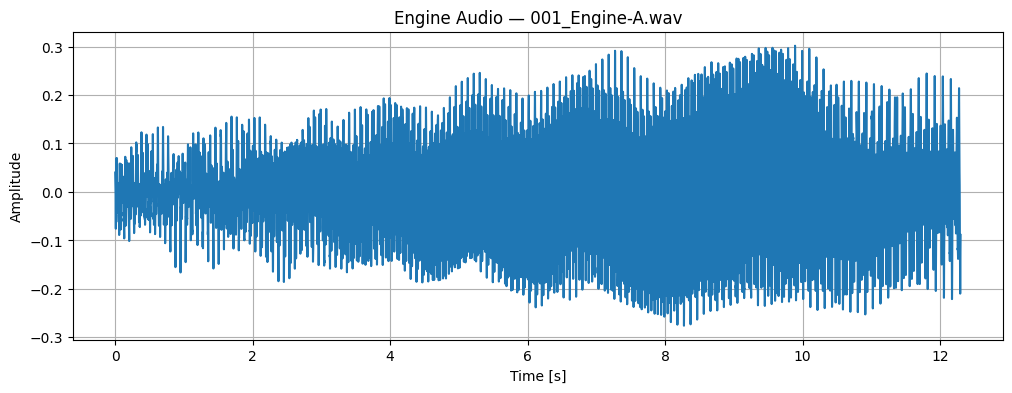

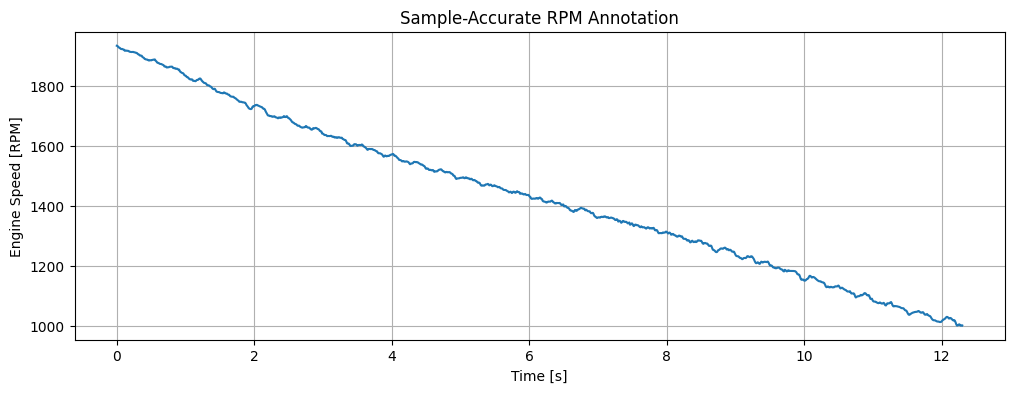

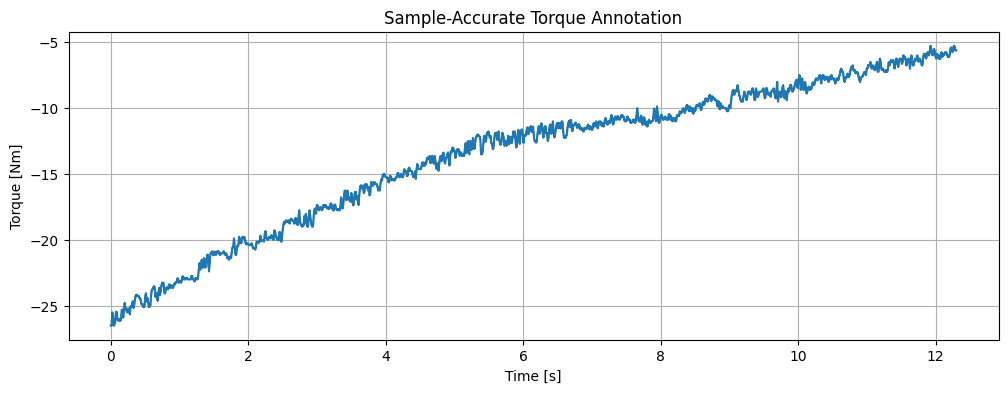

In [60]:
## Step-7: Plot one complete example
# Produce 3 eperate figures & Listen to stereo signal

# Engine Waveform
import matplotlib.pyplot as plt

time_s = np.arange(len(engine_left)) / sample_rate

plt.figure(figsize=(12, 4))
plt.plot(time_s, engine_left)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title(f"Engine Audio — {example_path.name}")
plt.grid(True)
plt.show()

# RPM Trace
plt.figure(figsize=(12, 4))
plt.plot(time_s, rpm_trace)
plt.xlabel("Time [s]")
plt.ylabel("Engine Speed [RPM]")
plt.title("Sample-Accurate RPM Annotation")
plt.grid(True)
plt.show()

# Torque Trace
plt.figure(figsize=(12, 4))
plt.plot(time_s, torque_trace_nm)
plt.xlabel("Time [s]")
plt.ylabel("Torque [Nm]")
plt.title("Sample-Accurate Torque Annotation")
plt.grid(True)
plt.show()

# Listening to stereo signal
# Engineering check is whether the audible pitch progression appears consistent with the RPM trace
from IPython.display import Audio

Audio(
    signal[:, :2].T,
    rate=sample_rate
)

In [62]:
## Step-8: Cross-check the WAV against supplied metadata
# For the same file, locate its metadata row
filename_column = "filename"  # Adjust after inspecting columns

metadata_row = stats_df.loc[
    stats_df[filename_column] == example_path.name
]

display(metadata_row)

# Compare calculated metrics vs. metadata metrics
calculated_stats = {
    "filename": example_path.name,
    "sample_rate_hz": sample_rate,
    "duration_s": len(signal) / sample_rate,
    "rpm_min": rpm_trace.min(),
    "rpm_max": rpm_trace.max(),
    "rpm_mean": rpm_trace.mean(),
    "rpm_std": rpm_trace.std(),
    "torque_min_nm": torque_trace_nm.min(),
    "torque_max_nm": torque_trace_nm.max(),
    "torque_mean_nm": torque_trace_nm.mean(),
    "torque_std_nm": torque_trace_nm.std(),
}

calculated_stats

,filename,samplerate,duration_sec,size_MB,rpm_min,rpm_max,rpm_mean,rpm_std,torque_min,torque_max,torque_mean,torque_std
0,001_Engine-A.wav,48000,12.3,4.504436,1000.366211,1934.204102,1435.016182,257.55354,-26.519775,-5.279541,-13.552642,5.556298


{'filename': '001_Engine-A.wav',
 'sample_rate_hz': 48000,
 'duration_s': 12.3,
 'rpm_min': np.float64(1000.3662109375),
 'rpm_max': np.float64(1934.2041015625),
 'rpm_mean': np.float64(1435.0161818630972),
 'rpm_std': np.float64(257.55354040453847),
 'torque_min_nm': np.float64(-26.519775390625),
 'torque_max_nm': np.float64(-5.279541015625),
 'torque_mean_nm': np.float64(-13.552642191651714),
 'torque_std_nm': np.float64(5.556297550424168)}

In [5]:
## Step-9: Build the Raw-File manifest. Code to create current raw manifest in Google Drive
# One row per originl WAV file
from pathlib import Path

import numpy as np
import pandas as pd
import soundfile as sf
from tqdm.auto import tqdm


AUDIO_DIR = (
    RAW_ROOT
    / "dataset"
    / "audio"
    / "A_full_set"
)

MANIFEST_DIR = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
)

MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

wav_files = sorted(AUDIO_DIR.glob("*.wav"))

print(f"WAV files found: {len(wav_files)}")


# Defining the inpection function
def inspect_raw_wav(
    wav_path: Path,
    raw_root: Path,
    file_id: str,
    subset_id: str = "A_full_set",
) -> dict:
    """
    Read one raw WAV file and return file-level metadata.

    One output dictionary becomes one row in the raw manifest.
    """

    record = {
        "file_id": file_id,
        "subset_id": subset_id,
        "original_filename": wav_path.name,
        "relative_file_path": str(
            wav_path.relative_to(raw_root)
        ),
        "sample_rate_hz": np.nan,
        "num_channels": np.nan,
        "num_samples": np.nan,
        "duration_s": np.nan,
        "file_size_mb": wav_path.stat().st_size / 1_000_000,
        "rpm_min": np.nan,
        "rpm_max": np.nan,
        "rpm_mean": np.nan,
        "rpm_std": np.nan,
        "torque_min_nm": np.nan,
        "torque_max_nm": np.nan,
        "torque_mean_nm": np.nan,
        "torque_std_nm": np.nan,
        "file_readable": False,
        "metadata_match": np.nan,
        "quality_flag": "review",
        "notes": "",
    }

    try:
        signal, sample_rate = sf.read(
            wav_path,
            always_2d=True,
        )

        num_samples, num_channels = signal.shape

        record.update(
            {
                "sample_rate_hz": sample_rate,
                "num_channels": num_channels,
                "num_samples": num_samples,
                "duration_s": num_samples / sample_rate,
                "file_readable": True,
            }
        )

        if num_channels != 4:
            record["notes"] = (
                f"Expected 4 channels; found {num_channels}."
            )
            return record

        rpm_trace = signal[:, 2] * 10_000
        torque_trace_nm = signal[:, 3] * 1_000

        record.update(
            {
                "rpm_min": float(np.min(rpm_trace)),
                "rpm_max": float(np.max(rpm_trace)),
                "rpm_mean": float(np.mean(rpm_trace)),
                "rpm_std": float(np.std(rpm_trace)),
                "torque_min_nm": float(np.min(torque_trace_nm)),
                "torque_max_nm": float(np.max(torque_trace_nm)),
                "torque_mean_nm": float(np.mean(torque_trace_nm)),
                "torque_std_nm": float(np.std(torque_trace_nm)),
                "quality_flag": "pass",
            }
        )

    except Exception as exc:
        record["quality_flag"] = "reject"
        record["notes"] = str(exc)

    return record


# Generating all rows
records = []

for index, wav_path in enumerate(tqdm(wav_files)):
    file_id = f"A-{index:04d}"

    record = inspect_raw_wav(
        wav_path=wav_path,
        raw_root=RAW_ROOT,
        file_id=file_id,
    )

    records.append(record)

raw_manifest = pd.DataFrame(records)


# Saving
manifest_path = (
    MANIFEST_DIR
    / "raw_file_manifest_v001.csv"
)

raw_manifest.to_csv(
    manifest_path,
    index=False,
)

print(f"Manifest saved to:\n{manifest_path}")


# Validating the completed manifest
assert len(raw_manifest) == len(wav_files), (
    "Manifest row count does not match WAV file count."
    )

assert raw_manifest["file_id"].is_unique, (
    "file_id values are not unique."
    )

assert raw_manifest["relative_file_path"].is_unique, (
    "Duplicate file paths found."
    )

assert raw_manifest["file_readable"].all(), (
    "At least one WAV file could not be read."
    )

print("Raw manifest validation passed.")
print(f"Manifest rows: {len(raw_manifest)}")


WAV files found: 767


  0%|          | 0/767 [00:00<?, ?it/s]

Manifest saved to:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/manifests/raw_file_manifest_v001.csv
Raw manifest validation passed.
Manifest rows: 767


In [6]:
## Step-10: Run the first dataset audit

# Summary checks
print(raw_manifest["file_readable"].value_counts())
print(raw_manifest["quality_flag"].value_counts())

display(
    raw_manifest[
        [
            "duration_s",
            "rpm_min",
            "rpm_max",
            "torque_min_nm",
            "torque_max_nm",
        ]
    ].describe()
)

file_readable
True    767
Name: count, dtype: int64
quality_flag
pass    767
Name: count, dtype: int64


,duration_s,rpm_min,rpm_max,torque_min_nm,torque_max_nm
count,767.000000,767.000000,767.000000,767.000000,767.000000
mean,11.531774,2637.915978,3784.518683,51.452637,211.003350
std,1.534565,1676.508772,1861.163456,164.499231,229.979526
min,4.117333,0.000000,0.000000,-107.025146,-101.776123
25%,11.253333,1146.087646,2133.331299,-68.450928,-4.806519
50%,12.300000,2381.896973,3652.648926,-13.519287,174.896240
75%,12.300000,3820.190430,5410.919189,157.241821,351.425171
max,12.300000,6826.782227,7007.446289,689.727783,718.475342
